In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#!pip install shap tensorflow

In [ ]:
#!ls /content/drive/MyDrive/Colab\ Notebooks

 10685642.zip
 ai_model_keras.keras
 ai_scaler.pkl
 aplication_ai_mlp.ipynb
 app_ai_scaler.pkl
 application_dataset.csv.gz
 application_gatekeeper.ipynb
 application_logs_kafka.ipynb
 Application_valid_layer.ipynb
 app_test_logs.csv
'ca (1).pem'
 ca_b.pem
 ca.pem
 client.truststore.jks
'Copy of NF-ToN-IoT-v3.csv'
 cryptography.ipynb
 csic_final.csv
'cybersecurity_threat_detection_logs (1).csv'
 cybersecurity_threat_detection_logs.csv
 dataset_20_percent.csv
 deep_ai_model.h5
 deep_ai_scaler.pkl
 df_refined.csv
 feature_columns.pkl
 files_split.ipynb
 forensic_audit.jsonl
 forensic_explanation.ipynb
 gatekeeper_network.pkl
 kept_logs_for_training.csv
 log_files_iot.zip
 mlp_application_model.h5
 mlp_feature_columns.pkl
 mlp_label_encoders.pkl
 mlp_model.keras
 mlp_scaler.pkl
 network_ai.ipynb
 network_ai_kept.ipynb
 network_flink.ipynb
 network_gatekeeper.ipynb
 network_logs.ipynb
 NF-ToN-IoT-v3.csv.gz
 NFV3DATA-A11964_A11964.zip
 nw_logs_2.ipynb
 OS_Ai.ipynb
 OS_ai_model.h5
 os_ai_mode

In [ ]:
# Load cryptography notebook
%run "/content/drive/MyDrive/Colab Notebooks/cryptography.ipynb"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MyDrive
🔐 Cryptographic keys ready.


In [ ]:
#print(freeze_log_structure)

<function freeze_log_structure at 0x7a20717298a0>


MODEL LOADED: windows
AI Risk Score: 2.0

================ INVESTIGATION REPORT ================

Log Source: WINDOWS
Risk Score: 2.0
Risk Level: High Risk
Decision: High Risk Behaviour

Model Evidence:
- Feature 'night_activity' with value '0.0' reduced anomaly likelihood (impact: 0.0086)
- Feature 'Event_ID' with value '5379.0' increased anomaly likelihood (impact: 0.0048)
- Feature 'hour_cos' with value '0.7071067811865474' increased anomaly likelihood (impact: 0.0037)
- Feature 'hour_sin' with value '-0.7071067811865477' increased anomaly likelihood (impact: 0.0002)


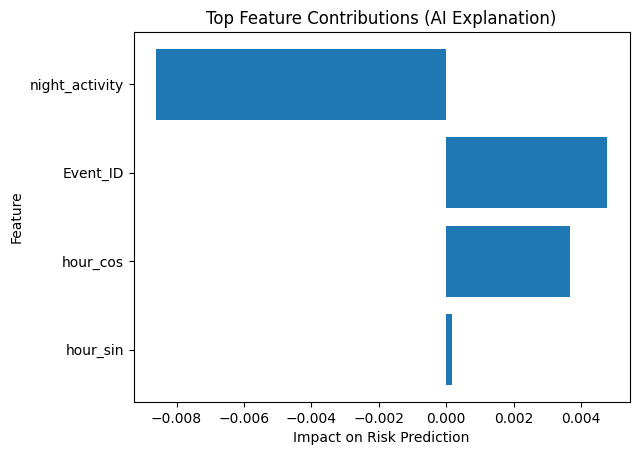


AI Interpretation:
- The anomaly score was primarily influenced by night_activity, Event_ID, hour_cos.
- High-risk behavioural indicators were observed. The event pattern significantly differs from expected baseline behaviour.
- Explanation derived from model attribution analysis using feature contribution scores.

Recommended Response:
- High-risk activity detected. Perform log correlation across related hosts and user accounts.
- Review associated authentication attempts and privilege usage.

Forensic reports saved: 171


In [ ]:
import shap
import joblib
import json
import pandas as pd
import numpy as np
from datetime import datetime, timezone
from tensorflow.keras.models import load_model

%run "/content/drive/MyDrive/Colab Notebooks/cryptography.ipynb"

# =====================================================
# MODEL REGISTRY
# =====================================================

MODEL_REGISTRY = {

"windows":{
"path":"/content/drive/MyDrive/Colab Notebooks/windows_threat_model.pkl",
"type":"sklearn",
"version":"windows_rf_v2"
},

"network":{
"path":"/content/drive/MyDrive/Colab Notebooks/gatekeeper_network.pkl",
"type":"sklearn",
"version":"network_rf_v1"
},

"linux":{
"path":"/content/drive/MyDrive/Colab Notebooks/os_log_model.pkl",
"type":"sklearn",
"version":"linux_rf_v1"
},

"application":{
"path":"/content/drive/MyDrive/Colab Notebooks/ai_model_keras.keras",
"type":"keras",
"version":"application_dl_v1"
}

}


LOG_SOURCE="windows"

config=MODEL_REGISTRY[LOG_SOURCE]


# =====================================================
# LOAD MODEL
# =====================================================

encoders={}
features=None
scaler=None

if config["type"]=="sklearn":

    package=joblib.load(config["path"])

    if isinstance(package,dict):

        model=package.get("model",package)
        features=package.get("features",None)
        encoders=package.get("encoders",{})

    else:

        model=package

else:

    model=load_model(config["path"],compile=False)

    scaler=joblib.load(
    "/content/drive/MyDrive/Colab Notebooks/ai_scaler.pkl"
    )


print("MODEL LOADED:",LOG_SOURCE)


# =====================================================
# SAMPLE LOGS
# =====================================================

sample_logs={
"windows":[{

"Event_ID":5379,
"hour_sin":-0.8,
"hour_cos":-0.5,
"night_activity":1,
"event_freq":25,
"burst_count":12,
"is_privileged_event":1,
"event_rarity":0.003,
"credential_attack_sequence":1

}],

"network":[{

"FLOW_START_MILLISECONDS":100000,
"FLOW_END_MILLISECONDS":100200,
"L4_SRC_PORT":51515,
"L4_DST_PORT":445,
"PROTOCOL":6,
"IN_BYTES":2000,
"IN_PKTS":20,
"OUT_BYTES":800,
"OUT_PKTS":12,
"TCP_FLAGS":24

}],

"linux":[{

"_source.agent.ip":"192.168.1.5",
"_source.agent.name":"host1",
"_source.agent.id":"agent01",
"_source.data.audit.syscall":"execve",
"_source.data.audit.pid":1200,
"_source.data.audit.exe":"/usr/bin/sudo",
"_source.data.audit.success":"yes",
"_source.data.srcip":"192.168.1.10",
"effective_uid":0,
"executed_command":"sudo su",
"hour_sin":0.5,
"hour_cos":0.8

}],

"application":[{

"_source.agent.id":"agent01",
"_source.rule.level":3,
"_source.rule.id":1001,
"_source.id":"log001",
"hour_sin":0.6,
"hour_cos":0.7

}]

}

df=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/windows_ai_output.csv")

df.columns = df.columns.str.strip().str.replace(" ","_").str.lower()

#sample=df.sort_values("risk_score",ascending=False).head(1)
alerts = df[df["risk_score"] >= 2].head(50)
# capture risk score before feature alignment
sample =alerts.head(1)
risk_score=int(sample["risk_score"].iloc[0])


# sample=pd.DataFrame(sample_logs[LOG_SOURCE])


# =====================================================
# STRING → NUMERIC CONVERSION
# =====================================================

for col in sample.columns:

    if sample[col].dtype=="object":

        sample[col]=sample[col].astype(str).apply(
        lambda x: hash(x)%100000
        )


# =====================================================
# FEATURE ALIGNMENT
# =====================================================

expected_features=None

if hasattr(model,"feature_names_in_"):

    expected_features=list(model.feature_names_in_)

elif scaler is not None and hasattr(scaler,"feature_names_in_"):

    expected_features=list(scaler.feature_names_in_)

if expected_features is not None:

    missing=[f for f in expected_features if f not in sample.columns]

    if missing:

        zeros=pd.DataFrame(
        np.zeros((len(sample),len(missing))),
        columns=missing
        )

        sample=pd.concat([sample,zeros],axis=1)

    sample=sample[expected_features]


# =====================================================
# SCALING
# =====================================================

if scaler is not None:

    sample=pd.DataFrame(
    scaler.transform(sample),
    columns=scaler.feature_names_in_
    )


# =====================================================
# PREDICTION
# =====================================================

if config["type"]=="sklearn" and LOG_SOURCE!="windows":

    risk_score = int(sample["risk_score"].iloc[0])

else:

    risk_score=float(model.predict(sample).flatten()[0])


print("AI Risk Score:",risk_score)
# =====================================================
# DECISION LOGIC
# =====================================================

if risk_score >= 3:
    decision = "Critical Threat Detected"
elif risk_score == 2:
    decision = "High Risk Behaviour"
elif risk_score == 1:
    decision = "Medium Risk Behaviour"
else:
    decision = "Normal Behaviour"


# =====================================================
# SHAP EXPLANATION
# =====================================================

shap_values=None
top_features=[]

try:

    if config["type"]=="sklearn":

        explainer=shap.TreeExplainer(model)
        shap_values=explainer(sample)

        values = shap_values.values[0]

        # Handle different SHAP output formats safely

        if isinstance(values, list):
            values = values[int(risk_score)][0]

        elif len(values.shape) == 3:
            # multiclass: (samples, classes, features)
            values = values[0][int(risk_score)]

        elif len(values.shape) == 2:
            # normal case: (samples, features)
            values = values[0]

        else:
            values = values

        importance=[]

        for f,v in zip(sample.columns,values):

            importance.append((f,abs(v)))

        importance=sorted(
        importance,key=lambda x:x[1],reverse=True
        )

        top_features=[x[0] for x in importance[:4]]

except:

    pass


# =====================================================
# EVIDENCE DRIVEN FORENSIC REPORT ENGINE
# =====================================================

def generate_forensic_report(sample, shap_values, risk_score, decision, source):

    log_data = sample.iloc[0].to_dict()

    report = {}

    report["log_source"] = source
    report["risk_score"] = round(risk_score,3)
    report["decision"] = decision
    risk_map={
        0:"Normal",
        1:"Medium",
        2:"High Risk",
        3:"Critical"
        }

    report["risk_level"]=risk_map.get(int(risk_score),"Unknown")

    # -------------------------------
    # FEATURE CONTRIBUTION ANALYSIS
    # -------------------------------

    evidence = []

    if shap_values is not None:

        values = shap_values.values

        # Safe extraction
        if isinstance(values, list):
            values = values[int(risk_score)][0]

        elif len(values.shape) == 3:
            values = values[0][int(risk_score)]

        elif len(values.shape) == 2:
            values = values[0]

        contributions = []

        for feature, impact in zip(sample.columns, values):

            impact_value = float(impact)

            contributions.append({
                "feature": feature,
                "value": log_data.get(feature),
                "impact": impact_value,
                "abs_impact": abs(impact_value)
            })

        contributions = sorted(
            contributions,
            key=lambda x:x["abs_impact"],
            reverse=True
        )

        top = contributions[:5]

        for item in top:

            direction = "increased" if item["impact"]>0 else "reduced"

            evidence.append({
                "feature":item["feature"],
                "value":item["value"],
                "effect":direction,
                "impact_strength":round(item["abs_impact"],4)
            })

    report["model_evidence"] = evidence


    # -------------------------------
    # BEHAVIOUR INTERPRETATION
    # -------------------------------

    interpretation = []

    if evidence:

        features = [e["feature"] for e in evidence]

        interpretation.append(
            "The anomaly score was primarily influenced by "
            + ", ".join(features[:3]) + "."
        )

        if risk_score >= 3:

            interpretation.append(
            "Critical behavioural anomaly detected. Multiple high-impact features strongly deviate from normal system activity patterns."
            )

        elif risk_score >= 2:

            interpretation.append(
            "High-risk behavioural indicators were observed. The event pattern significantly differs from expected baseline behaviour."
            )

        elif risk_score >= 1:

            interpretation.append(
            "Moderate anomaly detected. Some attributes diverge from typical activity but do not strongly indicate a confirmed attack."
            )

        else:

            interpretation.append(
            "The observed activity aligns with normal baseline behaviour of the monitored system."
            )

    interpretation.append(
        "Explanation derived from model attribution analysis using feature contribution scores."
    )

    report["interpretation"] = interpretation
    # -------------------------------
    # RESPONSE STRATEGY
    # -------------------------------

    response_actions = []

    severity = risk_score

    if severity >= 3:

        response_actions.append(
        "Immediate SOC analyst investigation required. Isolate affected system if suspicious behaviour persists."
        )

        response_actions.append(
        "Correlate this event with authentication, privilege escalation, and credential access logs."
        )

    elif severity >= 2:

        response_actions.append(
        "High-risk activity detected. Perform log correlation across related hosts and user accounts."
        )

        response_actions.append(
        "Review associated authentication attempts and privilege usage."
        )

    elif severity >= 1:

        response_actions.append(
        "Moderate anomaly observed. Continue monitoring for behavioural persistence."
        )

        response_actions.append(
        "Check surrounding system logs for related suspicious activity."
        )

    else:

        response_actions.append(
        "Activity appears normal. No immediate response required."
        )

    report["recommended_response"] = response_actions

    return report


# =====================================================
# REPORT GENERATION
# =====================================================

reports = []

for _, row in alerts.iterrows():

    sample = pd.DataFrame([row])
    missing = [f for f in features if f not in sample.columns]

    if missing:
        for m in missing:
            sample[m] = 0

    # Align features with model
    sample = sample[features]

    # Convert any object columns safely
    for col in sample.columns:
        if sample[col].dtype == "object":
            sample[col] = sample[col].astype(str).apply(lambda x: hash(x) % 100000)

    risk_score = int(row["risk_score"])

    if 'explainer' in globals():
        shap_values = explainer(sample)
    else:
        shap_values = None
    report = generate_forensic_report(
        sample,
        shap_values,
        risk_score,
        decision,
        LOG_SOURCE
    )

    reports.append(report)

# =====================================================
# FORENSIC REPORT FORMATTER
# =====================================================

def format_forensic_report(report):

    print("\n================ INVESTIGATION REPORT ================\n")

    print("Log Source:", report["log_source"].upper())
    print("Risk Score:", report["risk_score"])
    print("Risk Level:", report["risk_level"])
    print("Decision:", report["decision"])

    print("\nModel Evidence:")

    for e in report["model_evidence"]:

        print(
        f"- Feature '{e['feature']}' with value '{e['value']}' "
        f"{e['effect']} anomaly likelihood "
        f"(impact: {e['impact_strength']})"
        )

    # =====================================================
    # FEATURE IMPACT VISUALIZATION
    # =====================================================

    import matplotlib.pyplot as plt

    if shap_values is not None:

        values = shap_values.values

        if isinstance(values, list):
            values = values[int(risk_score)][0]

        elif len(values.shape) == 3:
            values = values[0][int(risk_score)]

        elif len(values.shape) == 2:
            values = values[0]

        feature_names = list(sample.columns)

        # force same length
        min_len = min(len(feature_names), len(values))

        feature_names = feature_names[:min_len]
        impacts = values[:min_len]

        impact_df = pd.DataFrame({
            "feature": feature_names,
            "impact": impacts
        })

        impact_df["abs_impact"] = impact_df["impact"].abs()

        impact_df = impact_df.sort_values("abs_impact", ascending=False).head(6)

        plt.figure()

        plt.barh(
            impact_df["feature"],
            impact_df["impact"]
        )

        plt.title("Top Feature Contributions (AI Explanation)")
        plt.xlabel("Impact on Risk Prediction")
        plt.ylabel("Feature")

        plt.gca().invert_yaxis()

        plt.show()
    print("\nAI Interpretation:")

    for line in report["interpretation"]:
        print("-", line)

    print("\nRecommended Response:")

    for r in report["recommended_response"]:
        print("-", r)

    print("\n====================================================")


format_forensic_report(report)

import pandas as pd
import json

FILE_PATH="/content/drive/MyDrive/Colab Notebooks/"

alerts=pd.read_csv(FILE_PATH+"windows_attack_patterns.csv")

reports=[]

for _,row in alerts.iterrows():

    report={

        "attack":row["attack"],
        "technique":row["technique"],
        "mitre_id":row["mitre_id"],
        "severity":row["severity"],
        "start_time":str(row["start_time"]),
        "end_time":str(row["end_time"]),

        "analysis":
        f"Attack pattern '{row['attack']}' detected using behavioral correlation. "
        f"Mapped to MITRE technique {row['mitre_id']}."

    }
    if(LOG_SOURCE == "windows"):
            severity_map = {
                "LOW_RISK":0,
                "MEDIUM_RISK":1,
                "HIGH_RISK":2
            }

    severity_value = severity_map.get(str(row["severity"]).upper(),1)

    evidence = create_signed_evidence(
        report,
        severity_value,
        config["version"],
        LOG_SOURCE
    )
    reports.append(evidence)

with open(FILE_PATH+"forensic_reports.json","w") as f:
    json.dump(reports,f,indent=2)

print("Forensic reports saved:",len(reports))


In [ ]:

# reasoning,context,response = forensic_analysis(
#     sample.iloc[0].to_dict(),
#     risk_score,
#     decision,
#     LOG_SOURCE
# )


# print("\n================ INVESTIGATION REPORT ================")

# print("\nLog Source:",LOG_SOURCE.upper())

# print("\nLog Data:")
# print(sample.iloc[0].to_dict())

# print("\nAI Risk Score:",round(risk_score,3))

# decision="Suspicious Behaviour Detected" if risk_score>0.5 else "Normal Behaviour"

# print("\nAI Decision:",decision)

# print("\nAI Forensic Reasoning:")

# for r in reasons:

#     print("-",r)


# print("\nPotential Risk Context:")

# for c in context:
#     print("-",c)

# print("\nRecommended Response:")

# for r in response:
#     print("-",r)


# print("\n====================================================")

In [ ]:
# report = generate_forensic_report(
#     sample,
#     shap_values,
#     risk_score,
#     decision,
#     LOG_SOURCE
# )



# # =====================================================
# # FORENSIC REPORT FORMATTER
# # =====================================================

# def format_forensic_report(report):

#     print("\n================ AI FORENSIC REPORT ================\n")

#     print("Log Source:", report["log_source"].upper())
#     print("Risk Score:", report["risk_score"])
#     print("Decision:", report["decision"])

#     print("\nModel Evidence:")

#     for e in report["model_evidence"]:

#         print(
#         f"- Feature '{e['feature']}' with value '{e['value']}' "
#         f"{e['effect']} anomaly likelihood "
#         f"(impact: {e['impact_strength']})"
#         )

#     print("\nAI Interpretation:")

#     for line in report["interpretation"]:
#         print("-", line)

#     print("\nRecommended Response:")

#     for r in report["recommended_response"]:
#         print("-", r)

#     print("\n====================================================")


# format_forensic_report(report)

# import pandas as pd
# import json

# FILE_PATH="/content/drive/MyDrive/Colab Notebooks/"

# alerts=pd.read_csv(FILE_PATH+"windows_attack_patterns.csv")

# reports=[]

# for _,row in alerts.iterrows():

#     report={

#         "attack":row["attack"],
#         "technique":row["technique"],
#         "mitre_id":row["mitre_id"],
#         "severity":row["severity"],
#         "start_time":str(row["start_time"]),
#         "end_time":str(row["end_time"]),

#         "analysis":
#         f"Attack pattern '{row['attack']}' detected using behavioral correlation. "
#         f"Mapped to MITRE technique {row['mitre_id']}."

#     }

#     reports.append(report)

# with open(FILE_PATH+"forensic_reports.json","w") as f:
#     json.dump(reports,f,indent=2)

# print("Forensic reports saved:",len(reports))

NameError: name 'decision' is not defined

In [ ]:
# import joblib

# model_path = "/content/drive/MyDrive/Colab Notebooks/windows_risk_engine.pkl"

# package = joblib.load(model_path)

# if isinstance(package, dict):
#     model = package.get("model", package)
#     features = package.get("features", None)
# else:
#     model = package
#     features = None

# print("MODEL LOADED\n")

# # Print saved features
# if features is not None:
#     print("Features stored in package:\n")
#     print(features)

# # Print sklearn detected features
# if hasattr(model, "feature_names_in_"):
#     print("\nFeatures used by model:\n")
#     print(list(model.feature_names_in_))


# import joblib

# model_path = "/content/drive/MyDrive/Colab Notebooks/gatekeeper_network.pkl"

# package = joblib.load(model_path)

# if isinstance(package, dict):
#     model = package.get("model", package)
#     features = package.get("features", None)
# else:
#     model = package
#     features = None

# print("MODEL LOADED\n")

# if features:
#     print("Features stored in package:")
#     print(features)

# if hasattr(model, "feature_names_in_"):
#     print("\nFeatures used by model:")
#     print(list(model.feature_names_in_))


# import joblib

# model_path = "/content/drive/MyDrive/Colab Notebooks/os_log_model.pkl"

# package = joblib.load(model_path)

# if isinstance(package, dict):
#     model = package.get("model", package)
#     features = package.get("features", None)
# else:
#     model = package
#     features = None

# print("MODEL LOADED\n")

# if features:
#     print("Features stored in package:")
#     print(features)

# if hasattr(model, "feature_names_in_"):
#     print("\nFeatures used by model:")
#     print(list(model.feature_names_in_))

# from tensorflow.keras.models import load_model

# model_path = "/content/drive/MyDrive/Colab Notebooks/ai_model_keras.keras"

# model = load_model(model_path, compile=False)

# print("MODEL LOADED\n")

# print("Input shape of model:")
# print(model.input_shape)

# print("\nNumber of features expected:")
# print(model.input_shape[1])


# import joblib

# scaler = joblib.load("/content/drive/MyDrive/Colab Notebooks/ai_scaler.pkl")

# print("Features used by application model:\n")
# print(list(scaler.feature_names_in_))

FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Colab Notebooks/windows_risk_engine.pkl'